# Ask “gene vs. location”—which explains the gradient?
## a) Correlation and regression
- Simple correlation:
    - Corr(gradient_score, x-coordinate)
    - Corr(gradient_score, y-coordinate)
If one is high, that axis of location explains your gradient.

- Multi-variable linear model:

```
### in pandas or statsmodels
model = sm.OLS(gradient, sm.add_constant(df[['x','y']])).fit()
print(model.rsquared)  # how much of gradient is explained by location
Partial correlation: Control for location when asking “does gene expression still predict gradient?”
```

## b) Variance partitioning
Use R’s vegan::varpart (or Python equivalent) to split variance in gene expression into fractions explained by (A) spatial coordinates and (B) gene-derived PC1.

## c) Canonical correlation / Procrustes
- CCA: Between the two data matrices [genes] and [spatial coords] to find shared axes.
- Procrustes test: Align your low-D embedding to the point cloud of spatial coordinates; a low Procrustes distance means they’re isomorphic.

## d) Generalized additive models (GAMs)


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
all_spatial= adata_mer.obsm['spatial']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
all_spatial*= 25

In [3]:
# load pseudoclusters

df = pd.read_csv('/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/spatial_with_pseudocluster.csv')
pc = df['pseudocluster'].values


In [5]:
[np.corrcoef(pc, all_spatial[:,i])[0,1] for i in range(3)]

[np.float64(0.3784354510517028),
 np.float64(-0.506312896466377),
 np.float64(0.4606574462918817)]

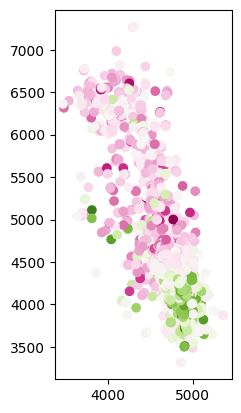

In [12]:
plt.scatter(all_spatial[:,2], all_spatial[:,1], c= pc, cmap ='PiYG')
plt.gca().set_aspect('equal')

In [ ]:
statsmodels.

In [20]:
import statsmodels.api as sm

X_xyz = sm.add_constant(all_spatial)
model = sm.OLS(pc, X_xyz).fit()
print(model.rsquared)  # how much of gradient is explained by location


0.28352277081481414


In [22]:

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     349.2
Date:                Fri, 30 May 2025   Prob (F-statistic):          5.02e-191
Time:                        14:54:05   Log-Likelihood:                 2092.3
No. Observations:                2651   AIC:                            -4177.
Df Residuals:                    2647   BIC:                            -4153.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5060      0.144     -3.526      0.0

In [23]:

X_gene = sm.add_constant(adata_mer.X.toarray())
model = sm.OLS(pc,X_gene).fit()
print(model.rsquared)  # how much of gradient is explained by location

print(model.summary())

0.9045954532899863
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     70.54
Date:                Fri, 30 May 2025   Prob (F-statistic):               0.00
Time:                        17:34:27   Log-Likelihood:                 4764.8
No. Observations:                2651   AIC:                            -8900.
Df Residuals:                    2336   BIC:                            -7047.
Df Model:                         314                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.6387     19.755 